# AQI Prediction Project — Exploratory Data Analysis

# Objective

This EDA helps understand:
- Data quality
- Missing values
- AQI distribution
- AQI trends over time
- Relationship between pollutants and AQI
- Relationship between weather and AQI
- Feature correlations
- Model comparison for AQI prediction

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("assets", exist_ok=True)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [45]:
import os
import hopsworks
import pandas as pd
from dotenv import load_dotenv

In [46]:
load_dotenv()
HOPSWORKS_KEY = os.getenv("HOPSWORKS_API_KEY")

project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai",
    project="aqi_project_10pearls",
    api_key_value=HOPSWORKS_KEY
)

fs = project.get_feature_store()

fg = fs.get_feature_group(
    name="aqi_features",
    version=1
)

df = fg.read()
df.head()

2026-05-20 09:57:53,177 INFO: Closing external client and cleaning up certificates.
2026-05-20 09:57:53,178 INFO: Connection closed.
2026-05-20 09:57:53,178 INFO: Initializing external client
2026-05-20 09:57:53,178 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-20 09:57:55,237 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32913
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.79s) 


,timestamp,city,aqi,pm25,pm10,o3,no2,so2,co,temp,...,hour_sin,hour_cos,month_sin,month_cos,aqi_change_rate,aqi_rolling_6h,aqi_rolling_24h,target_aqi_3h,target_aqi_24h,target_aqi_72h
0,2026-05-04 03:00:00+00:00,Karachi,125.0,29.99,85.19,110.59,0.36,0.53,128.01,32.6,...,0.707107,0.707107,5.000000e-01,-8.660254e-01,0.0,150.0,139.583333,125.0,125.0,125.0
1,2025-12-25 05:00:00+00:00,Karachi,125.0,44.68,79.67,122.92,1.75,10.03,310.01,19.8,...,0.965926,0.258819,-2.449294e-16,1.000000e+00,0.0,125.0,147.916667,175.0,125.0,300.0
2,2025-10-20 15:00:00+00:00,Karachi,125.0,30.25,74.14,95.38,0.17,0.64,130.01,28.1,...,-0.707107,-0.707107,-8.660254e-01,5.000000e-01,0.0,125.0,125.000000,125.0,175.0,300.0
3,2026-03-31 21:00:00+00:00,Karachi,125.0,9.71,28.13,115.39,0.15,0.44,116.11,24.0,...,-0.707107,0.707107,1.000000e+00,6.123234e-17,0.0,125.0,125.000000,125.0,125.0,125.0
4,2025-11-02 00:00:00+00:00,Karachi,175.0,58.80,113.56,99.19,0.10,0.46,180.71,23.1,...,0.000000,1.000000,-5.000000e-01,8.660254e-01,0.0,175.0,227.083333,175.0,300.0,175.0


This data was loaded from Hopsworks Feature Store using the `aqi_features` feature group.

# Data Summary

In [6]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (8650, 28)
Columns: ['timestamp', 'city', 'aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'pressure', 'wind_speed', 'wind_deg', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'aqi_change_rate', 'aqi_rolling_6h', 'aqi_rolling_24h', 'target_aqi_3h', 'target_aqi_24h', 'target_aqi_72h']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8650 entries, 0 to 8649
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype                  
---  ------           --------------  -----                  
 0   timestamp        8650 non-null   datetime64[us, Etc/UTC]
 1   city             8650 non-null   object                 
 2   aqi              8650 non-null   float64                
 3   pm25             8650 non-null   float64                
 4   pm10             8650 non-null   float64                
 5   o3               8650 non-null   float64                
 6   no2              8650 non-null   float64                
 7   so2              8650 non-null   float64                
 8   co               8650 non-null   float64                
 9   temp             8650 non-null   float64                
 10  humidity         8650 non-null   float64                
 11  pressure         8650 non-null   float64                
 12  wind_speed       865

In [8]:
df.isnull().sum().sort_values(ascending=False)

target_aqi_72h     55
target_aqi_24h     30
target_aqi_3h       9
city                0
aqi_rolling_24h     0
aqi_rolling_6h      0
aqi_change_rate     0
month_cos           0
month_sin           0
hour_cos            0
hour_sin            0
is_weekend          0
month               0
day_of_week         0
timestamp           0
wind_deg            0
wind_speed          0
pressure            0
humidity            0
temp                0
co                  0
so2                 0
no2                 0
o3                  0
pm10                0
pm25                0
aqi                 0
hour                0
dtype: int64

In [47]:
df_clean = df.dropna(subset=["target_aqi_24h", "target_aqi_72h"]).copy()

print("Original shape:", df.shape)
print("Missing target rows after dropping:", df_clean.shape)

Original shape: (8650, 28)
Missing target rows after dropping: (8595, 28)


In [48]:
df_clean.isnull().sum().sort_values(ascending=False)

timestamp          0
city               0
target_aqi_24h     0
target_aqi_3h      0
aqi_rolling_24h    0
aqi_rolling_6h     0
aqi_change_rate    0
month_cos          0
month_sin          0
hour_cos           0
hour_sin           0
is_weekend         0
month              0
day_of_week        0
hour               0
wind_deg           0
wind_speed         0
pressure           0
humidity           0
temp               0
co                 0
so2                0
no2                0
o3                 0
pm10               0
pm25               0
aqi                0
target_aqi_72h     0
dtype: int64

In [49]:
print("Original rows:", df.shape[0])
print("Clean rows:", df_clean.shape[0])
print("Rows dropped:", df.shape[0] - df_clean.shape[0])

print("Original columns:", df.shape[1])
print("Clean columns:", df_clean.shape[1])

Original rows: 8650
Clean rows: 8595
Rows dropped: 55
Original columns: 28
Clean columns: 28


# AQI Stats

In [12]:
df["aqi"].describe()

count    8650.000000
mean      139.252601
std        63.690872
min        25.000000
25%       125.000000
50%       125.000000
75%       175.000000
max       300.000000
Name: aqi, dtype: float64

# AQI Distribution

2026-05-20 09:53:06,729 WARNING: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.



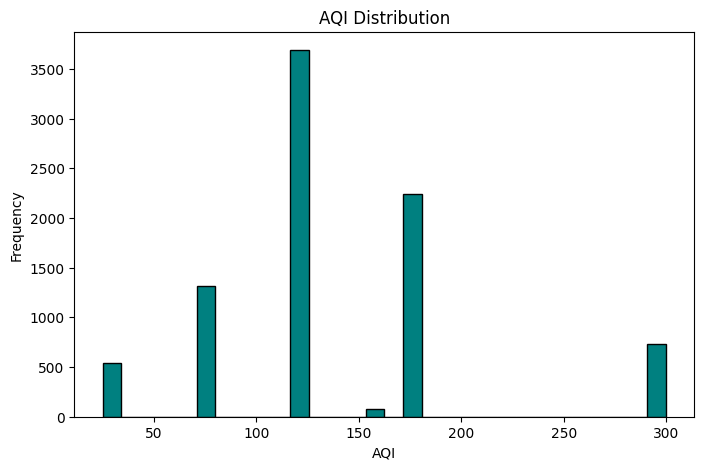

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["aqi"].dropna(), bins=30, color="teal", edgecolor="black")
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# AQI category count

2026-05-20 09:53:06,836 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



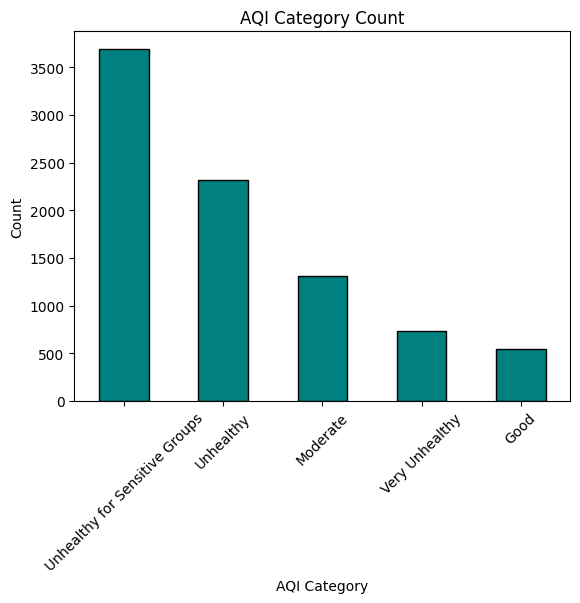

In [14]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df_clean["aqi_category"] = df_clean["aqi"].apply(aqi_category)

df_clean["aqi_category"].value_counts().plot(kind="bar", color="teal", edgecolor="black")
plt.title("AQI Category Count")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# AQI by day of week

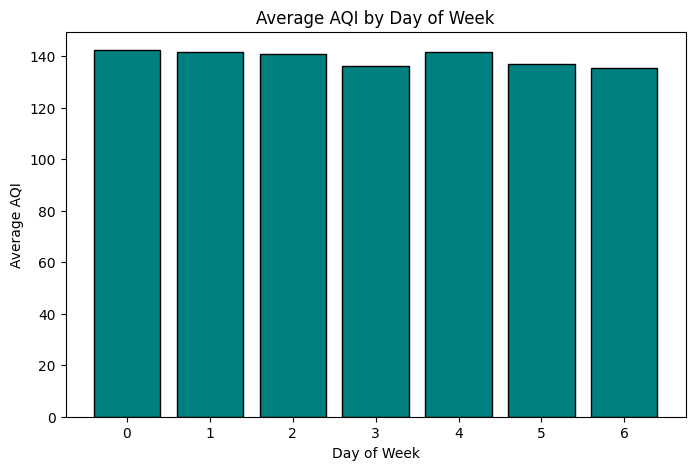

In [15]:
day_aqi = df_clean.groupby("day_of_week")["aqi"].mean()

plt.figure(figsize=(8,5))
plt.bar(day_aqi.index, day_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.show()

# AQI Trend Over Time

2026-05-20 09:53:07,116 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



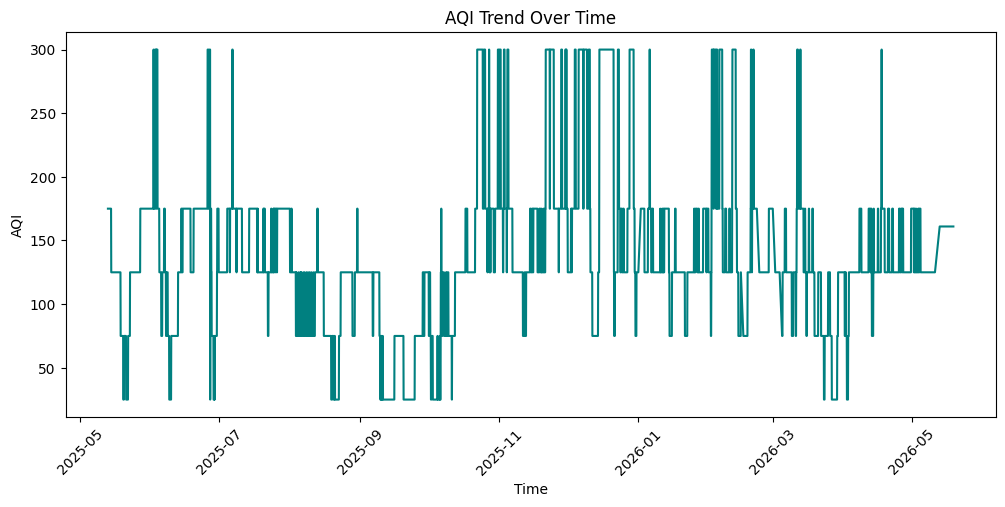

In [16]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

df_sorted = df_clean.sort_values("timestamp")

plt.figure(figsize=(12, 5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], color="teal")
plt.title("AQI Trend Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap

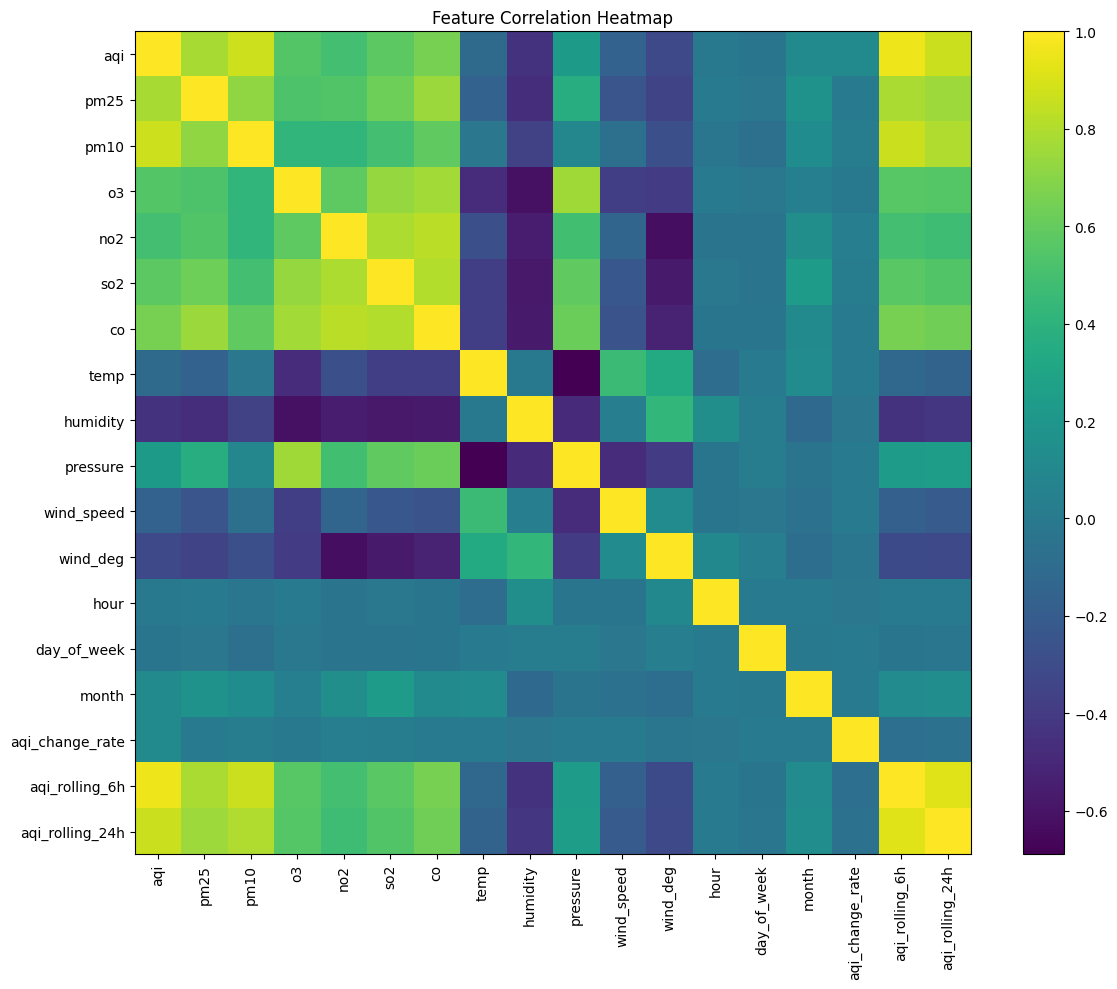

In [17]:
corr_cols = [
    "aqi", "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]

corr = df_clean[corr_cols].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="viridis", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [18]:
corr_with_aqi = df_clean.corr(numeric_only=True)["aqi"].sort_values(ascending=False)
corr_with_aqi

aqi                1.000000
aqi_rolling_6h     0.959194
target_aqi_3h      0.918482
pm10               0.869411
aqi_rolling_24h    0.866409
pm25               0.780447
target_aqi_24h     0.658253
co                 0.652041
so2                0.573833
o3                 0.550194
no2                0.494045
target_aqi_72h     0.363555
pressure           0.230109
month_cos          0.227710
month              0.121909
month_sin          0.121002
aqi_change_rate    0.118753
hour_sin           0.012944
hour              -0.005939
is_weekend        -0.030088
day_of_week       -0.032600
hour_cos          -0.032878
temp              -0.104225
wind_speed        -0.157100
wind_deg          -0.316166
humidity          -0.441827
Name: aqi, dtype: float64

# Correlation Findings

Rolling AQI and pollutant features showed strong relationships with AQI. This confirms that recent AQI trends and pollutant concentrations are important for AQI forecasting.

# Average AQI by Hour

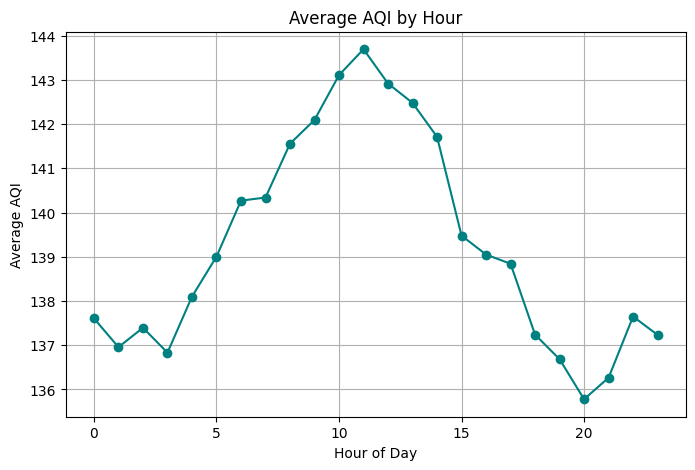

In [19]:
hourly_aqi = df_clean.groupby("hour")["aqi"].mean()
plt.figure(figsize=(8, 5))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o", color="teal")
plt.title("Average AQI by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

# Average AQI by Month

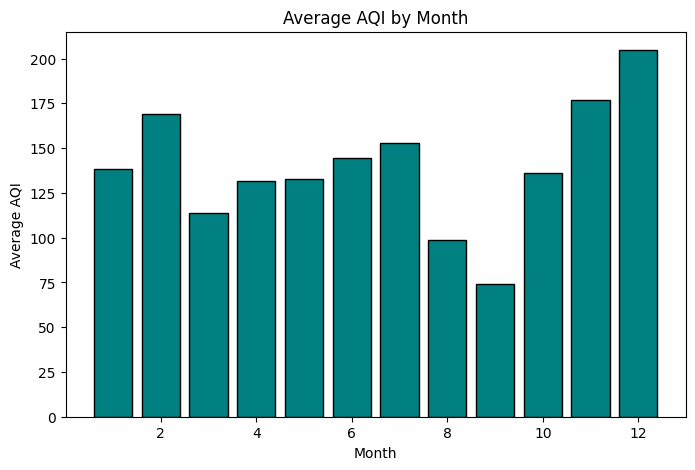

In [20]:
monthly_aqi = df_clean.groupby("month")["aqi"].mean()

plt.figure(figsize=(8, 5))
plt.bar(monthly_aqi.index, monthly_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

# Pollutants vs AQI

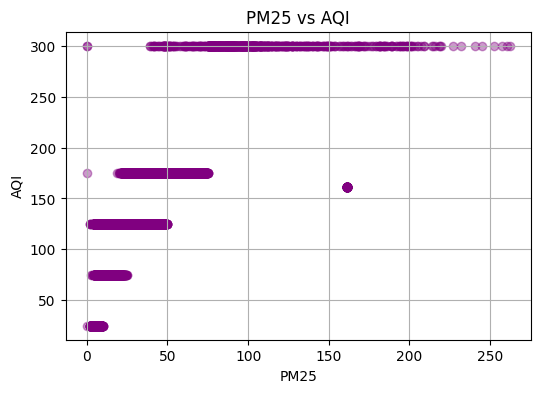

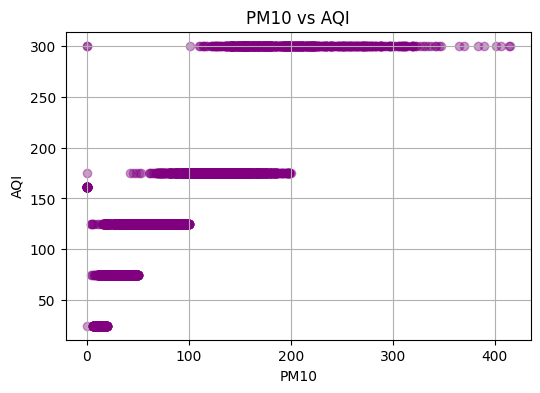

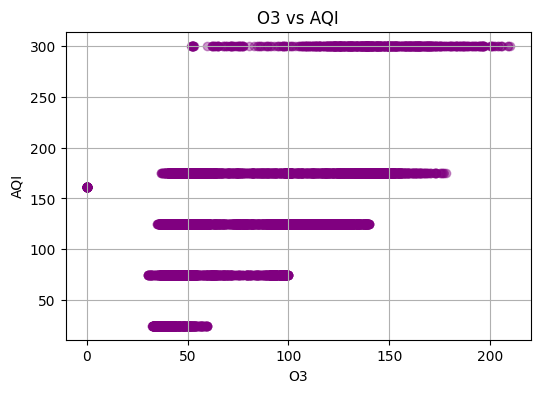

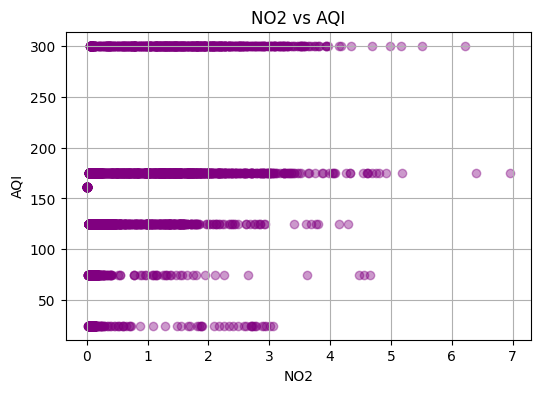

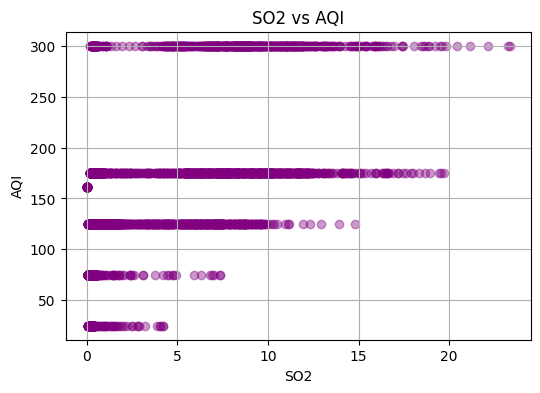

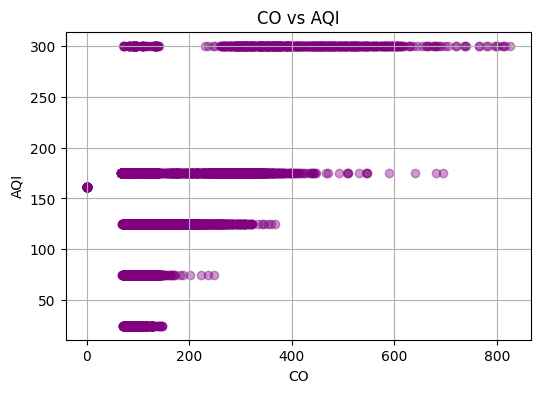

In [21]:
pollutants = ["pm25", "pm10", "o3", "no2", "so2", "co"]

for col in pollutants:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="purple")
    plt.title(f"{col.upper()} vs AQI")
    plt.xlabel(col.upper())
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Weather vs AQI

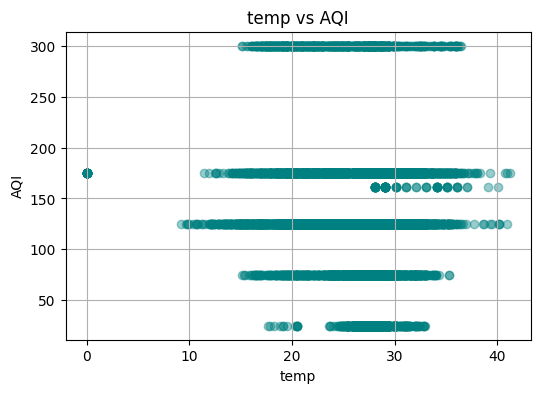

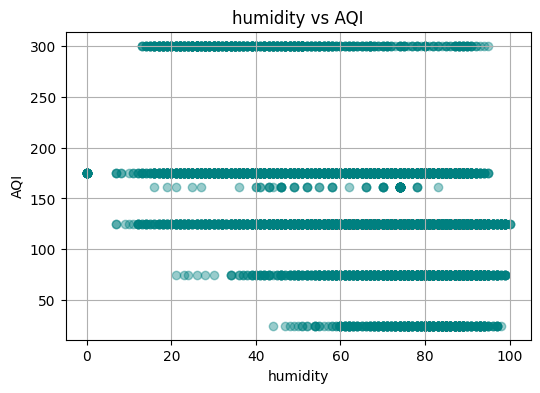

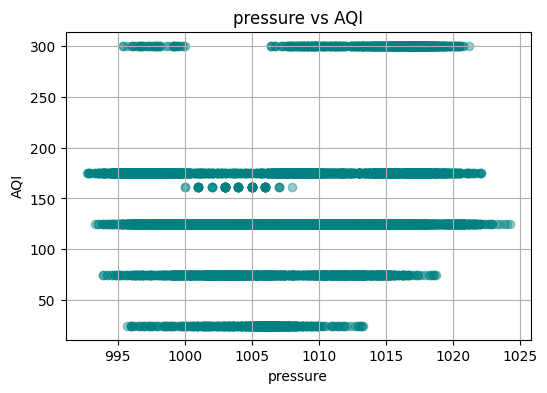

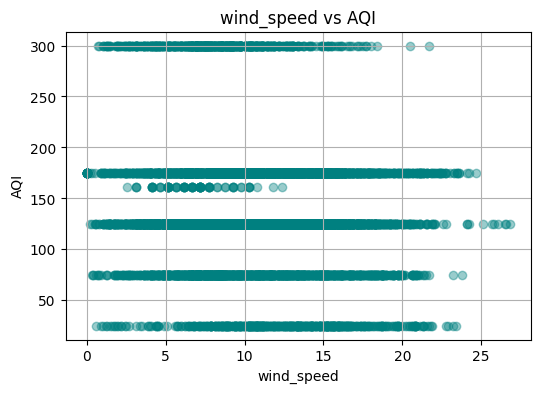

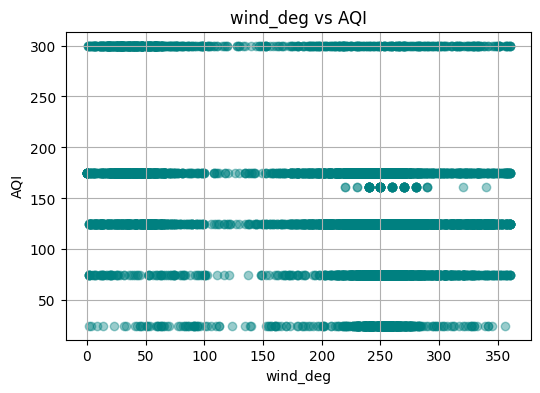

In [22]:
weather_cols = ["temp", "humidity", "pressure", "wind_speed", "wind_deg"]

for col in weather_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="teal")
    plt.title(f"{col} vs AQI")
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Outliers

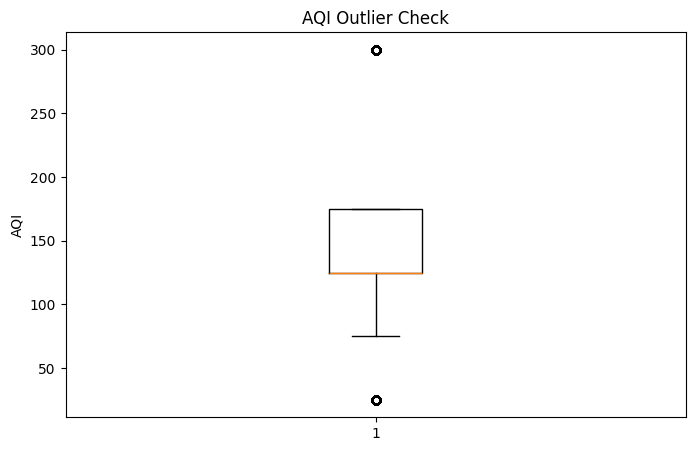

In [23]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["aqi"].dropna())
plt.title("AQI Outlier Check")
plt.ylabel("AQI")
plt.show()

# Rolling AQI trend

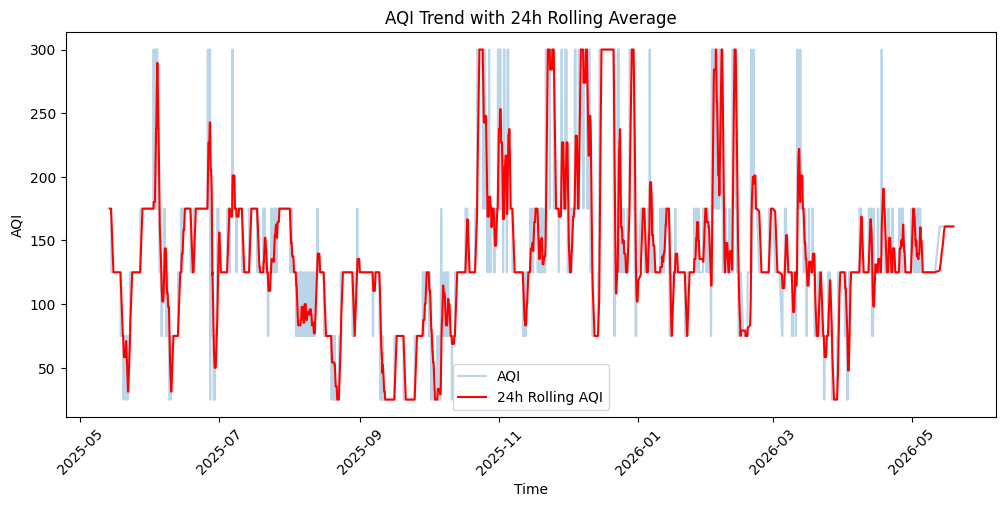

In [24]:
df_sorted = df_clean.sort_values("timestamp")
df_sorted["aqi_rolling_mean"] = df_sorted["aqi"].rolling(24).mean()

plt.figure(figsize=(12,5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], alpha=0.3, label="AQI")
plt.plot(df_sorted["timestamp"], df_sorted["aqi_rolling_mean"], color="red", label="24h Rolling AQI")
plt.title("AQI Trend with 24h Rolling Average")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Model Training and Evaluation


In [25]:
# AQI prediction is a regression problem, so we use MAE, RMSE, and R².
target_col = "target_aqi_72h"
feature_cols = [
    "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

In [26]:
X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6876, 22)
Testing data: (1719, 22)


In [27]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [28]:
linear_preds = linear_model.predict(X_test)

In [29]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression Results")
print(f"RMSE: {linear_rmse:.3f}")
print(f"MAE: {linear_mae:.3f}")
print(f"R² Score: {linear_r2:.3f}")

Linear Regression Results
RMSE: 56.490
MAE: 42.677
R² Score: 0.257


In [30]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

Ridge()

In [31]:
ridge_preds = ridge_model.predict(X_test)

In [32]:
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

print("Ridge Regression Results")
print("MAE:", round(ridge_mae, 3))
print("RMSE:", round(ridge_rmse, 3))
print("R²:", round(ridge_r2, 3))

Ridge Regression Results
MAE: 42.677
RMSE: 56.49
R²: 0.257


In [33]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [34]:
rf_preds = rf_model.predict(X_test)

In [35]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE:", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²:", round(rf_r2, 3))

Random Forest Results
MAE: 12.749
RMSE: 22.478
R²: 0.882


In [36]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [37]:
gb_preds = gb_model.predict(X_test)

In [38]:
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting Results")
print("MAE:", round(gb_mae, 3))
print("RMSE:", round(gb_rmse, 3))
print("R²:", round(gb_r2, 3))

Gradient Boosting Results
MAE: 31.985
RMSE: 43.274
R²: 0.564


# Model Comparision

In [39]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

results_df = results_df.round(3)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,42.677,56.490,0.257
1,Ridge Regression,42.677,56.490,0.257
2,Random Forest,12.749,22.478,0.882
3,Gradient Boosting,31.985,43.274,0.564


In [40]:
best_model = results_df.sort_values("RMSE").iloc[0]

print("Best Model Based on Lowest RMSE:")
print(best_model)

Best Model Based on Lowest RMSE:
Model    Random Forest
MAE             12.749
RMSE            22.478
R2               0.882
Name: 2, dtype: object


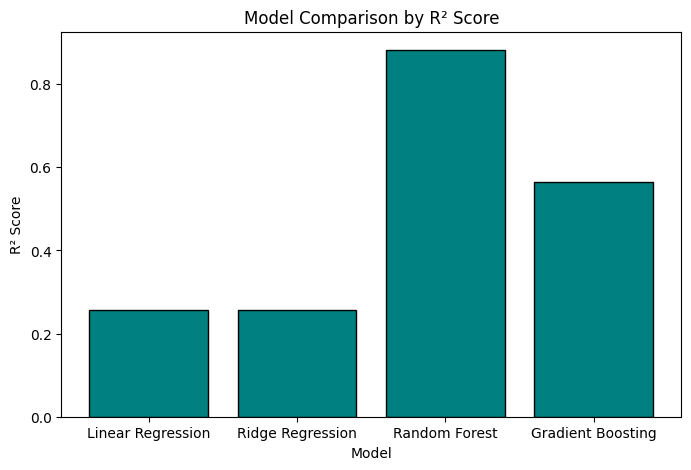

In [41]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"], color="teal", edgecolor="black")
plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

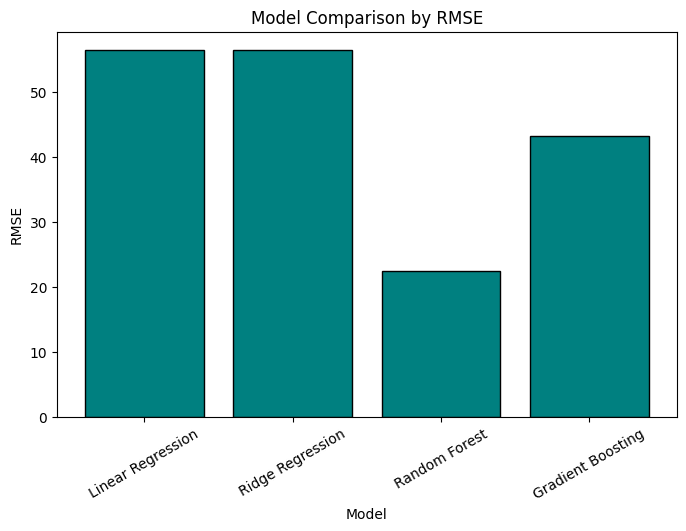

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"], color="teal", edgecolor="black")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

# Model Training and Evaluation Finding

Random Forest performed best in the notebook as it is based on random train-test split.

But in AQI forecasting it is a time-dependent prediction problem. A random split can mix future observations with past observations, which may produce overly optimistic results.

For production, time-series validation is more appropriate because the model is trained on earlier records and tested on later unseen records.

The production training pipeline uses time-aware evaluation and registered Gradient Boosting as the final production model in Hopsworks Model Registry.

Therefore, Random Forest was kept as part of the notebook experiment, while Gradient Boosting was used as the final production model.

In [51]:
TARGET = "target_aqi_72h"

FEATURES = [
    c for c in df.columns
    if c not in ["target_aqi_3h", "target_aqi_24h", "target_aqi_72h", "timestamp", "city"]
]

df_model = df.dropna(subset=FEATURES + [TARGET]).sort_values("timestamp").copy()

X = df_model[FEATURES]
y = df_model[TARGET]

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    }

# Random split
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

rf_random = RandomForestRegressor(n_estimators=100, random_state=42)
gb_random = GradientBoostingRegressor(n_estimators=100, random_state=42)

rf_random.fit(X_train_random, y_train_random)
gb_random.fit(X_train_random, y_train_random)

# Time-series split
split_index = int(len(X) * 0.8)

X_train_time = X.iloc[:split_index]
X_test_time = X.iloc[split_index:]

y_train_time = y.iloc[:split_index]
y_test_time = y.iloc[split_index:]

rf_time = RandomForestRegressor(n_estimators=100, random_state=42)
gb_time = GradientBoostingRegressor(n_estimators=100, random_state=42)

rf_time.fit(X_train_time, y_train_time)
gb_time.fit(X_train_time, y_train_time)

comparison_df = pd.DataFrame([
    {"Model": "Random Forest", "Split": "Random", **evaluate_model(rf_random, X_test_random, y_test_random)},
    {"Model": "Gradient Boosting", "Split": "Random", **evaluate_model(gb_random, X_test_random, y_test_random)},
    {"Model": "Random Forest", "Split": "Time-Series", **evaluate_model(rf_time, X_test_time, y_test_time)},
    {"Model": "Gradient Boosting", "Split": "Time-Series", **evaluate_model(gb_time, X_test_time, y_test_time)},
])

comparison_df.round(3)

,Model,Split,MAE,RMSE,R2
0,Random Forest,Random,12.287,21.815,0.882
1,Gradient Boosting,Random,30.127,41.100,0.581
2,Random Forest,Time-Series,44.545,60.966,-1.390
3,Gradient Boosting,Time-Series,36.997,52.551,-0.776


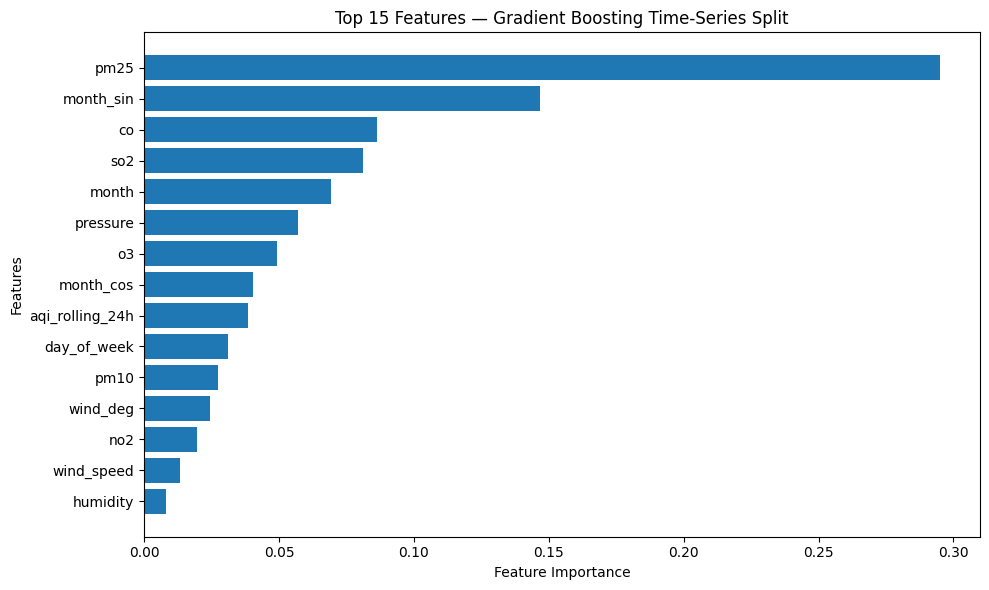

In [44]:
import os
os.makedirs("assets", exist_ok=True)

importances = gb_time.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=True)
    .tail(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_df["feature"], feature_importance_df["importance"])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Top 15 Features — Gradient Boosting Time-Series Split")

plt.tight_layout()
plt.savefig("assets/eda_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## EDA Findings

- The dataset contains AQI, pollutant, weather, time-based, rolling, and target features.
- Missing values mainly appeared in future target columns, which is expected for live/latest rows.
- AQI values vary over time, confirming that forecasting is meaningful.
- Pollutant features such as PM2.5, PM10, O3, NO2, SO2, and CO were important for AQI analysis.
- Rolling AQI features showed strong relationships with AQI.
- Weather features were included because weather conditions affect pollutant concentration and movement.
- Random Forest performed best in the notebook random split experiment.
- Gradient Boosting was selected as the production model based on pipeline evaluation and Hopsworks Model Registry.
- For temporal or sequential data, time-based validation is preferred over random splitting.